# Core Tests: Does VTA Dopamine Encode Movement Direction, Not Reward?

## Central Hypothesis

**DA neurons encode kinematic/behavioral variables (movement direction, force generation) rather than reward prediction error (RPE).**

Forward vs Backward movements should produce distinct trajectories in PC space. The latent variables driving variance should reflect movement direction, not reward value.

## Experimental Setup

| Dataset | Aligned to | Contains | Reward? |
|---------|-----------|----------|---------|
| **SpontFB** | Spontaneous movement onset (t=600) | Pure movement, no task | No |
| **CRFB** | Conditioned Response onset (t=600) | CR movement, CS/reward shuffled | Yes (shuffled) |
| **ToneFB** | CS tone onset (t=600) | CS burst, then CR movement, then reward at t=700 | Yes (t=700) |

- **Forward/Backward:** Mouse moves toward a sugar tube placed in front or behind (session-determined, no choice).
- **Neuron classes:** DA (DF, DB, D, DFB) and GABA (GF, GB, G, GFB). F=forward-selective, B=backward-selective, FB=bidirectional.
- **Two phasic DA bursts in ToneFB:** (1) at CS onset = salience/sensory, (2) near reward delivery = our claim: CR movement signal.
- **CR timing:** Variable reaction time ~30-100 timesteps (0.3-1.0s) after CS.

## Six Core Tests

1. **SpontFB cross-projection:** Does the pure-movement subspace explain task data?
2. **Per-class separation:** Do DF/DB/GF/GB show significant direction selectivity?
3. **GF/GB reward insensitivity:** Are GABA direction neurons blind to reward?
4. **Reward-time deflection:** Is there a speed transient at reward delivery?
5. **CS vs CR direction sensitivity (NEW):** Is the CS burst direction-invariant while the CR burst is direction-selective?
6. **CR burst in movement subspace:** Does reward-time DA activity live in the SpontFB movement subspace?


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr
import logging
import importlib

import plot_pca_framework
importlib.reload(plot_pca_framework)

from plot_pca_framework import (
    load_dataset,
    extract_neuron_data,
    extract_group_averaged_data,
    fit_pca,
    project_onto_pca,
    analyze_dataset,
    cross_project,
    compute_reconstruction_r2,
    compute_trajectory_metrics,
    slice_window,
    smooth_trajectories,
    build_overlay_figure,
    plot_1d_pc_timecourses,
    plot_speed_profiles,
    compute_rdm,
    compare_rdms,
    EPOCHS,
    # Null models
    null_cross_projection_r2,
    null_separation,
    null_reward_deflection,
    # Private helpers
    _align_neuron_data,
    _phase_randomise,
)

logging.basicConfig(level=logging.WARNING)
%matplotlib inline
plt.rcParams["figure.dpi"] = 100

# ── Configuration ──
DATASETS = {
    'SpontFB': {'mat_file': 'dataSpontFB.mat', 'var_name': 'dataSpontFB'},
    'CRFB':    {'mat_file': 'dataCRFB.mat',    'var_name': 'dataCRFB'},
    'ToneFB':  {'mat_file': 'dataToneFB.mat',  'var_name': 'dataToneFB'},
}
DA_GROUPS   = ['DF', 'DB', 'D', 'DFB']
GABA_GROUPS = ['GF', 'GB', 'G', 'GFB']
ALL_GROUPS  = DA_GROUPS + GABA_GROUPS

N_COMPONENTS = 3
EVENT_IDX    = 600
WINDOW       = 150
DT           = 0.01
SG_WINDOW    = 11
SG_ORDER     = 3
MIN_NEURONS  = 10


In [14]:
# Run all 9 dataset x population analyses
results = {}
combos = {'Dopamine': DA_GROUPS, 'GABA': GABA_GROUPS}

for ds_name, ds_cfg in DATASETS.items():
    for combo_label, groups in combos.items():
        key = f"{ds_name}_{combo_label}"
        try:
            r = analyze_dataset(
                mat_file=ds_cfg['mat_file'], var_name=ds_cfg['var_name'],
                dataset_name=ds_name, neuron_groups=groups, combo_label=combo_label,
                n_components=N_COMPONENTS, event_idx=EVENT_IDX, window=WINDOW,
                dt=DT, sg_window=SG_WINDOW, sg_order=SG_ORDER)
            results[key] = r
            evr = r['explained_variance_ratio']
            print(f"OK  {key:25s}  n={r['n_neurons']:4d}  "
                  f"EVR=[{'+'.join(f'{v:.3f}' for v in evr)}]  "
                  f"sep={r['metrics']['mean_separation']:.2f}")
        except Exception as e:
            print(f"FAIL {key:25s}  {e}")

# Per-class PCA
single_class_results = {}
for ds_name, ds_cfg in DATASETS.items():
    for group in ALL_GROUPS:
        key = f"{ds_name}_{group}"
        try:
            r = analyze_dataset(
                mat_file=ds_cfg['mat_file'], var_name=ds_cfg['var_name'],
                dataset_name=ds_name, neuron_groups=[group], combo_label=group,
                n_components=N_COMPONENTS, event_idx=EVENT_IDX, window=WINDOW,
                dt=DT, sg_window=SG_WINDOW, sg_order=SG_ORDER)
            if r['n_neurons'] < MIN_NEURONS:
                print(f"SKIP {key:25s}  n={r['n_neurons']} < {MIN_NEURONS}")
                continue
            single_class_results[key] = r
            sep = r['metrics']['mean_separation']
            print(f"OK  {key:25s}  n={r['n_neurons']:4d}  sep={sep:.2f}")
        except Exception as e:
            print(f"SKIP {key:25s}  {e}")

print(f"\n9 population analyses: {len(results)}")
print(f"Per-class analyses (n >= {MIN_NEURONS}): {len(single_class_results)}")


OK  SpontFB_Dopamine           n= 730  EVR=[0.070+0.029+0.014]  sep=12.20
OK  SpontFB_GABA               n= 102  EVR=[0.389+0.111+0.044]  sep=19.60


OK  CRFB_Dopamine              n= 482  EVR=[0.088+0.020+0.019]  sep=11.45
OK  CRFB_GABA                  n= 155  EVR=[0.270+0.104+0.042]  sep=26.56


OK  ToneFB_Dopamine            n= 497  EVR=[0.209+0.038+0.029]  sep=7.82
OK  ToneFB_GABA                n= 155  EVR=[0.298+0.117+0.045]  sep=28.08
OK  SpontFB_DF                 n= 292  sep=8.41
OK  SpontFB_DB                 n= 130  sep=5.56
OK  SpontFB_D                  n= 142  sep=7.52
OK  SpontFB_DFB                n= 166  sep=8.39
OK  SpontFB_GF                 n=  25  sep=7.22
OK  SpontFB_GB                 n=  22  sep=18.42
OK  SpontFB_G                  n=  13  sep=3.38
OK  SpontFB_GFB                n=  42  sep=7.10
OK  CRFB_DF                    n= 231  sep=6.92
OK  CRFB_DB                    n=  70  sep=5.34
OK  CRFB_D                     n=  90  sep=4.37


OK  CRFB_DFB                   n=  91  sep=8.88
OK  CRFB_GF                    n=  27  sep=14.08
OK  CRFB_GB                    n=  42  sep=18.46
OK  CRFB_G                     n=  17  sep=4.27
OK  CRFB_GFB                   n=  69  sep=12.01
OK  ToneFB_DF                  n= 244  sep=6.50
OK  ToneFB_DB                  n=  70  sep=5.79
OK  ToneFB_D                   n=  90  sep=4.07


OK  ToneFB_DFB                 n=  93  sep=8.51
OK  ToneFB_GF                  n=  27  sep=14.81
OK  ToneFB_GB                  n=  42  sep=20.46
OK  ToneFB_G                   n=  17  sep=5.03
OK  ToneFB_GFB                 n=  69  sep=10.94

9 population analyses: 6
Per-class analyses (n >= 10): 24


### Data Summary

Examine the neuron counts and which classes were available above. Classes with fewer than 10 neurons are skipped (PCA unreliable). Key classes for hypothesis testing: **DF, DB, GF, GB** (direction-selective) and **GFB** (bidirectional GABA).

---


---
## Test 1: Does the Spontaneous-Movement Subspace Explain Task Neural Variance?

SpontFB has **no CS, no reward** -- only spontaneous F/B movements. If DA and GABA encode movement direction, PCs fitted on SpontFB group-averaged data should capture the majority of variance in CRFB and ToneFB.

**Method:** Average neurons within selectivity groups (DF/DB/D/DFB or GF/GB/G/GFB) to create 4 pseudo-neurons. Fit PCA on SpontFB groups, project Task groups. Compute R-squared. **Null model:** phase-randomise each group's timecourse independently (destroys temporal alignment, preserves autocorrelation spectrum).

**Prediction (movement):** R-squared > 0.70 for both DA and GABA, significantly above null. SpontFB PCs capture task variance because the same F/B movement drives activity in all datasets.

**Prediction (RPE):** R-squared lower for DA than GABA in the Task datasets. DA has value-related variance (CS, reward signals) in ToneFB/CRFB that SpontFB cannot explain. If DA R-squared is notably lower than GABA R-squared, the extra DA variance is non-movement (candidate: value).


  GABA: Spont->CRFB                    R2=0.9234  null=0.9130+/-0.0069  z=1.49  p=0.0500
  GABA: Spont->ToneFB                  R2=0.9305  null=0.9170+/-0.0073  z=1.85  p=0.0150
  Dopamine: Spont->CRFB                R2=0.9278  null=0.8003+/-0.0249  z=5.12  p=0.0010
  Dopamine: Spont->ToneFB              R2=0.9438  null=0.7988+/-0.0233  z=6.23  p=0.0010


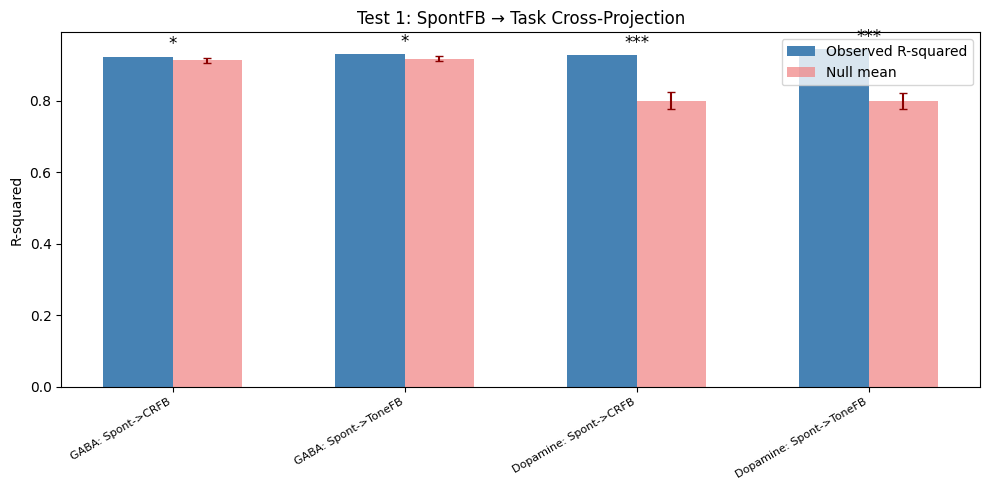

In [15]:
# Test 1: Group-averaged cross-projection + null model
cross_proj_results = {}

for combo_label, groups in [('GABA', GABA_GROUPS), ('Dopamine', DA_GROUPS)]:
    spont_key = f'SpontFB_{combo_label}'
    if spont_key not in results:
        continue

    for target_ds in ['CRFB', 'ToneFB']:
        target_key = f'{target_ds}_{combo_label}'
        if target_key not in results:
            continue

        # Forward: SpontFB → Task
        label = f'{combo_label}: Spont->{target_ds}'
        xp = cross_project(
            results[spont_key], results[target_key],
            use_group_avg=True, neuron_groups=groups,
            window=WINDOW, event_idx=EVENT_IDX, dt=DT,
            sg_window=SG_WINDOW, sg_order=SG_ORDER)
        r2_obs = xp['r2']

        # Null model (returns tuple: observed_r2, null_r2s, p_value)
        _, null_r2s, p_null = null_cross_projection_r2(
            results[spont_key]['data'], results[target_key]['data'],
            neuron_groups=groups, n_permutations=1000)

        null_mean = float(np.mean(null_r2s))
        null_std = float(np.std(null_r2s))
        z = (r2_obs - null_mean) / null_std if null_std > 0 else float('inf')
        p = float((np.sum(null_r2s >= r2_obs) + 1) / (len(null_r2s) + 1))

        cross_proj_results[label] = {
            'r2': r2_obs, 'null_mean': null_mean, 'null_std': null_std,
            'z': z, 'p': p, 'null_values': null_r2s}
        print(f"  {label:35s}  R2={r2_obs:.4f}  null={null_mean:.4f}+/-{null_std:.4f}  "
              f"z={z:.2f}  p={p:.4f}")

# Plot
labels = list(cross_proj_results.keys())
r2_vals = [cross_proj_results[l]['r2'] for l in labels]
null_means = [cross_proj_results[l]['null_mean'] for l in labels]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(labels))
ax.bar(x - 0.15, r2_vals, 0.3, label='Observed R-squared', color='steelblue')
ax.bar(x + 0.15, null_means, 0.3, label='Null mean', color='lightcoral', alpha=0.7)
# Error bars for null
ax.errorbar(x + 0.15, null_means,
            yerr=[cross_proj_results[l]['null_std'] for l in labels],
            fmt='none', color='darkred', capsize=3)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('R-squared')
ax.set_title('Test 1: SpontFB → Task Cross-Projection')
ax.legend()
# Add significance stars
for i, l in enumerate(labels):
    if cross_proj_results[l]['p'] < 0.001:
        ax.text(i, r2_vals[i] + 0.02, '***', ha='center', fontsize=12)
    elif cross_proj_results[l]['p'] < 0.01:
        ax.text(i, r2_vals[i] + 0.02, '**', ha='center', fontsize=12)
    elif cross_proj_results[l]['p'] < 0.05:
        ax.text(i, r2_vals[i] + 0.02, '*', ha='center', fontsize=12)
plt.tight_layout()
plt.show()


### Test 1 -- Interpretation

**Fill based on observed results:**
- Is R-squared > 0.70? → Movement subspace explains task data.
- Is DA R-squared similar to GABA R-squared? → Both encode movement (supports movement theory).
- Is DA R-squared notably lower than GABA? → DA may have extra non-movement variance (partial support for RPE).
- Are all p-values < 0.05? → Results significantly exceed autocorrelation-driven chance.

**Why DA R-squared may be lower than GABA:** ToneFB DA neurons have CS-evoked phasic bursts and reward-associated variance that is entirely absent from SpontFB (which has no CS, no reward). SpontFB PCs cannot capture this extra variance, so DA R-squared drops. If GABA is purely movement-encoding, SpontFB PCs explain nearly all GABA variance → higher R-squared. Importantly, **a DA-GABA gap does not prove RPE**: the extra DA variance could be a sensory/salience response to the CS rather than value coding.

---


## Test 2: Do DF/DB Show Distinct Opposite Trajectories? Do GF/GB Show Direction Selectivity?

If DA encodes movement direction, forward-selective (DF) and backward-selective (DB) neurons should show strong, opposite F/B trajectories. Same for GF/GB in GABA.

**Method:** For each class with n >= 10 neurons, compute fwd-bwd separation in **multiple time windows** from the per-class PCA:
- **Pre-event** [-1.5, 0)s: baseline before alignment event (expect low separation)
- **Early post** [0, 0.5)s: movement onset phase
- **Late post** [0.5, 1.0)s: sustained movement
- **Around reward** [0.8, 1.2)s: reward delivery window (ToneFB reward at t=1.0s)
- **Full post-event** [0, 1.5)s: entire post-event period

"Post-event" = timepoints after the alignment event (t >= 0), i.e., after movement onset (SpontFB/CRFB) or CS onset (ToneFB).

**Null model:** Phase-randomise fwd and bwd PC timecourses independently (`_phase_randomise`), preserving autocorrelation but destroying cross-condition structure. Run once, extract window-specific null means. Null mean shown as dashed line.

**Normalization:** Raw separation depends on PC-space scale (varies across classes due to different neuron counts). To enable cross-class comparison, separation is also shown normalized by pre-event baseline (fold-change over baseline).

**Prediction (movement):** DF/DB have high separation in SpontFB AND CRFB. GF/GB high across all datasets. Separation should increase post-event (movement onset) and remain elevated.

**Prediction (RPE):** DA classes show lower separation than GABA. DF/DB separation weaker in ToneFB.


  CRFB_D                n= 90  pre=3.7  early=4.7  late=7.7  rew=7.6  full_post z=-2.8 ns
  CRFB_DB               n= 70  pre=5.0  early=7.4  late=6.2  rew=6.1  full_post z=-2.7 ns
  CRFB_DF               n=231  pre=6.6  early=9.3  late=6.8  rew=10.1  full_post z=-5.0 ns
  CRFB_DFB              n= 91  pre=9.9  early=7.7  late=10.0  rew=11.9  full_post z=-3.4 ns
  CRFB_G                n= 17  pre=3.7  early=4.7  late=4.5  rew=5.0  full_post z=-0.3 ns
  CRFB_GB               n= 42  pre=7.8  early=37.9  late=29.0  rew=23.4  full_post z=1.7 **
  CRFB_GF               n= 27  pre=9.3  early=23.4  late=17.1  rew=15.1  full_post z=1.9 *
  CRFB_GFB              n= 69  pre=7.4  early=18.7  late=17.8  rew=16.4  full_post z=-1.3 ns
  SpontFB_D             n=142  pre=9.2  early=6.0  late=6.8  rew=8.1  full_post z=-4.3 ns
  SpontFB_DB            n=130  pre=3.9  early=14.9  late=3.4  rew=3.1  full_post z=-0.6 ns
  SpontFB_DF            n=292  pre=10.1  early=12.7  late=3.9  rew=3.8  full_post z=-4.6 n

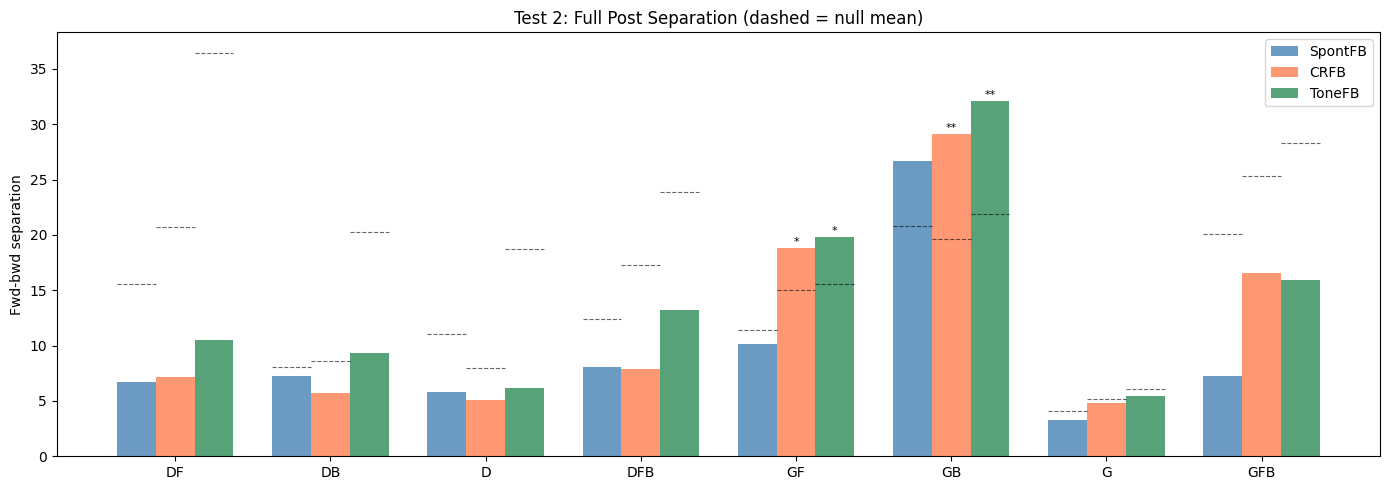

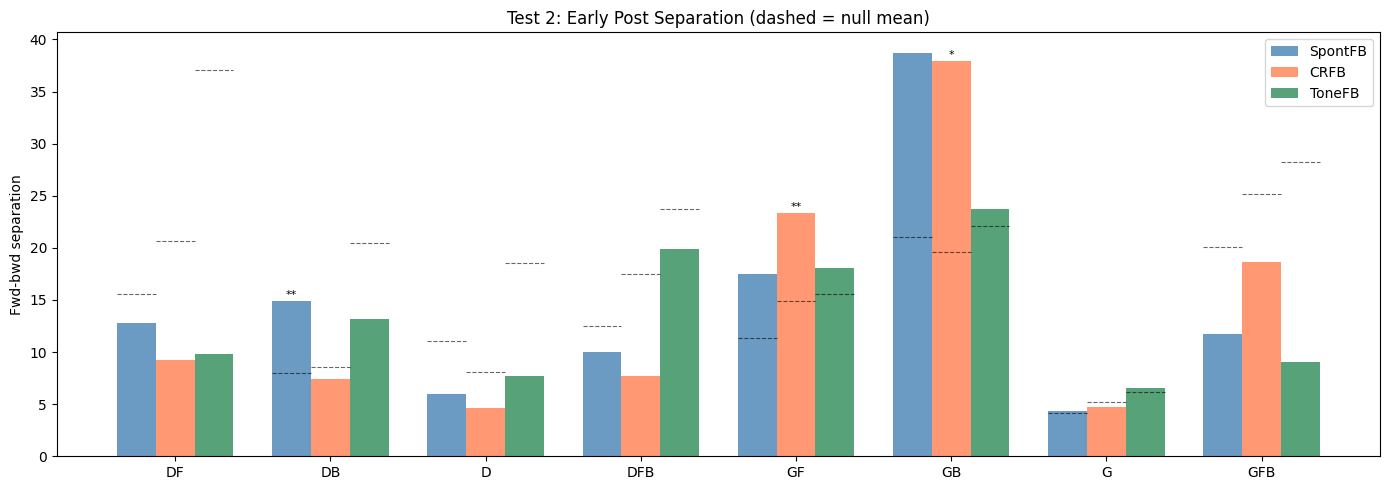

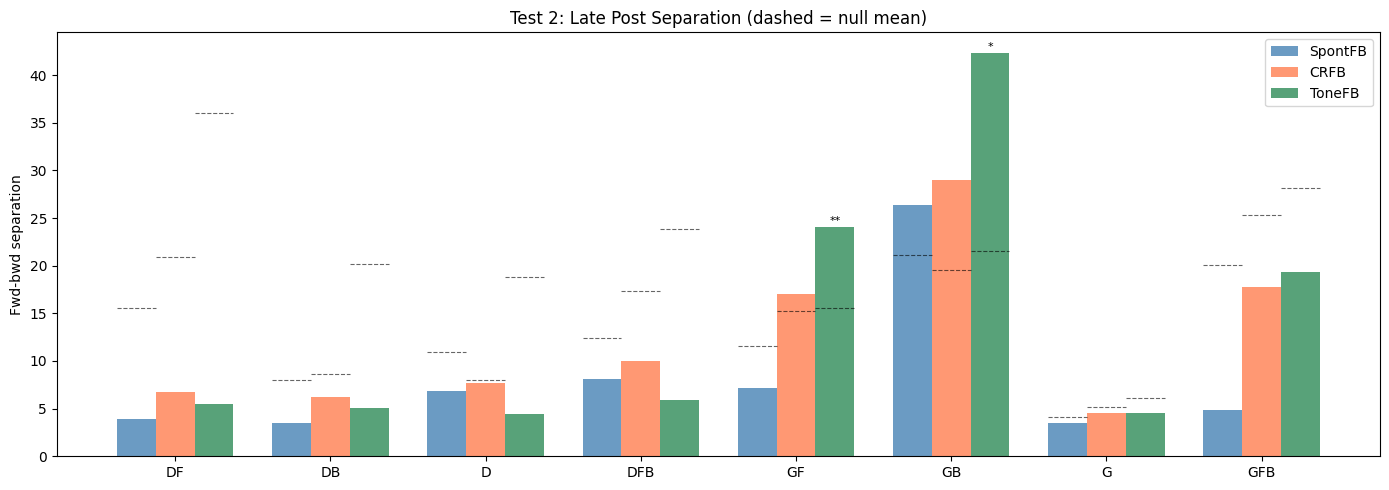

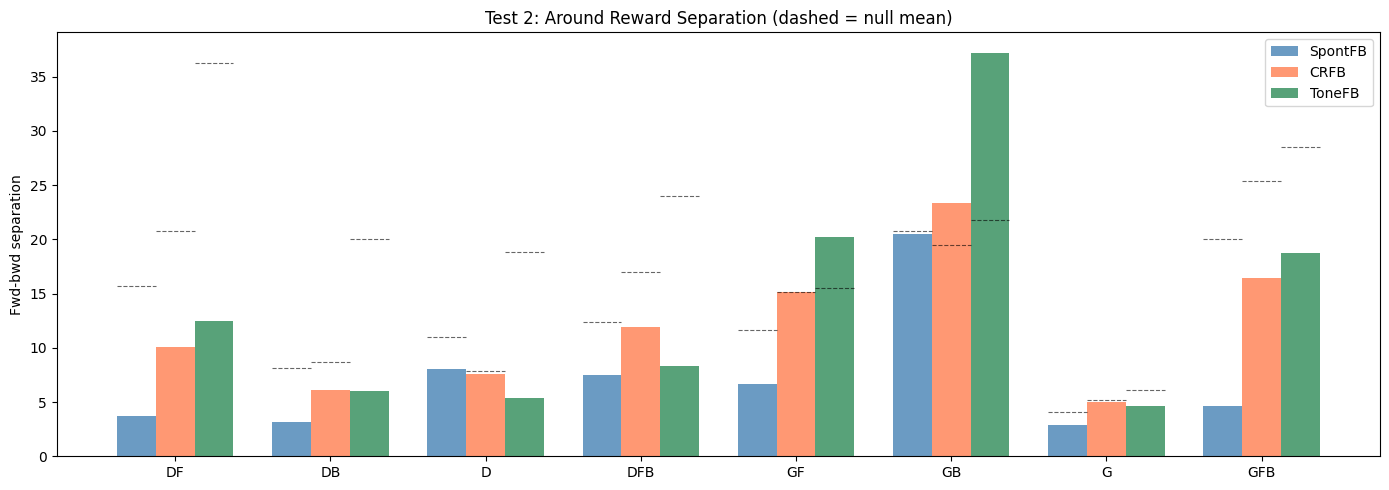

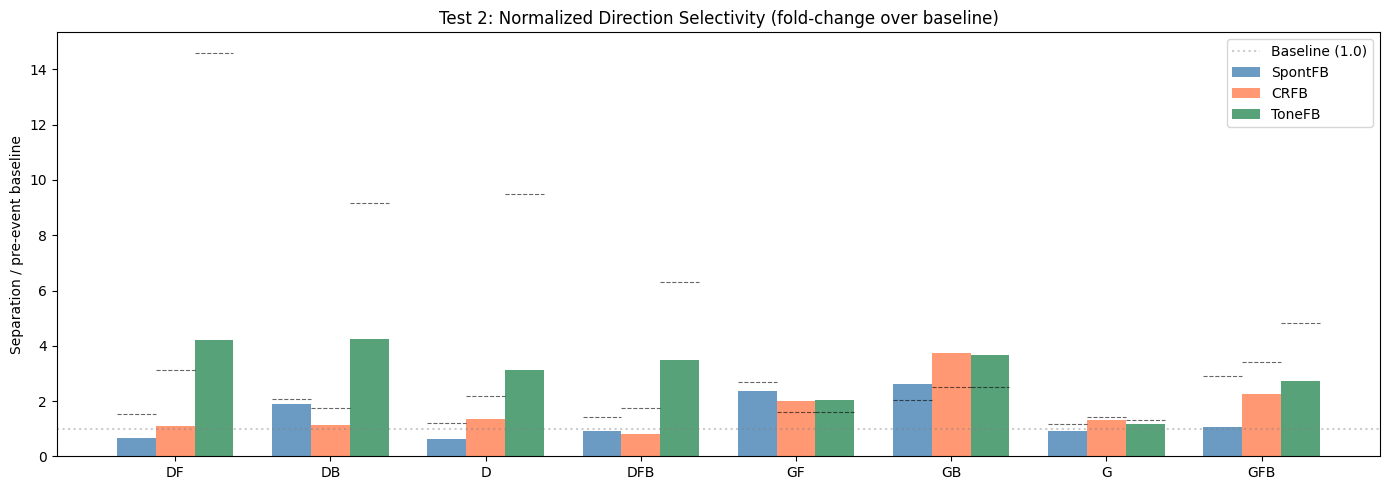

In [16]:
# Test 2: Per-class separation — multi-window + normalization + null model
N_PERMS_T2 = 1000
rng_t2 = np.random.default_rng(42)

# Define time windows (indices in windowed data; event at index WINDOW=150)
WIN_DEFS = {
    'pre_event':     slice(0, WINDOW),                    # [-1.5, 0) s
    'early_post':    slice(WINDOW, WINDOW + 50),          # [0, 0.5) s
    'late_post':     slice(WINDOW + 50, WINDOW + 100),    # [0.5, 1.0) s
    'around_reward': slice(WINDOW + 80, WINDOW + 120),    # [0.8, 1.2) s
    'full_post':     slice(WINDOW, 2 * WINDOW + 1),       # [0, 1.5] s
}

sep_results = []

for key, r in sorted(single_class_results.items()):
    ds_name = key.split('_')[0]
    cls_name = '_'.join(key.split('_')[1:])

    fwd = r['smooth_data']['fwd_smooth']  # (n_pcs, n_t)
    bwd = r['smooth_data']['bwd_smooth']

    # Full separation timecourse
    sep_t = np.sqrt(np.sum((fwd - bwd)**2, axis=0))

    # Observed window means
    obs_wins = {wn: float(np.mean(sep_t[ws])) for wn, ws in WIN_DEFS.items()}
    pre_baseline = obs_wins['pre_event']

    # Phase-randomise ONCE, store full null timecourses
    n_t = fwd.shape[1]
    null_tc = np.empty((N_PERMS_T2, n_t))
    for i in range(N_PERMS_T2):
        fwd_null = _phase_randomise(fwd, rng_t2)
        bwd_null = _phase_randomise(bwd, rng_t2)
        null_tc[i] = np.sqrt(np.sum((fwd_null - bwd_null)**2, axis=0))

    # Extract window-specific null distributions
    null_wins = {wn: np.mean(null_tc[:, ws], axis=1) for wn, ws in WIN_DEFS.items()}

    # p-value and z-score per window
    row = {'key': key, 'dataset': ds_name, 'class': cls_name,
           'n_neurons': r['n_neurons'], 'sep_t': sep_t, 'pre_baseline': pre_baseline}
    for wn in WIN_DEFS:
        obs_val = obs_wins[wn]
        null_arr = null_wins[wn]
        nm = float(np.mean(null_arr))
        ns = float(np.std(null_arr))
        zs = (obs_val - nm) / ns if ns > 0 else float('inf')
        pv = float((np.sum(null_arr >= obs_val) + 1) / (N_PERMS_T2 + 1))
        ratio = obs_val / pre_baseline if pre_baseline > 0 else np.nan
        null_ratio = nm / pre_baseline if pre_baseline > 0 else np.nan
        row[f'{wn}_sep'] = obs_val
        row[f'{wn}_null_mean'] = nm
        row[f'{wn}_z'] = zs
        row[f'{wn}_p'] = pv
        row[f'{wn}_ratio'] = ratio
        row[f'{wn}_null_ratio'] = null_ratio

    sep_results.append(row)
    sig_fp = '***' if row['full_post_p'] < 0.001 else '**' if row['full_post_p'] < 0.01 else '*' if row['full_post_p'] < 0.05 else 'ns'
    print(f"  {key:20s}  n={r['n_neurons']:3d}  "
          f"pre={obs_wins['pre_event']:.1f}  early={obs_wins['early_post']:.1f}  "
          f"late={obs_wins['late_post']:.1f}  rew={obs_wins['around_reward']:.1f}  "
          f"full_post z={row['full_post_z']:.1f} {sig_fp}")

# ── Plot 1: Multi-window bar chart (raw) with null mean dashed lines ──
sep_df = pd.DataFrame(sep_results)
classes_order = ['DF', 'DB', 'D', 'DFB', 'GF', 'GB', 'G', 'GFB']
ds_colors = {'SpontFB': 'steelblue', 'CRFB': 'coral', 'ToneFB': 'seagreen'}

for win_name in ['full_post', 'early_post', 'late_post', 'around_reward']:
    fig, ax = plt.subplots(figsize=(14, 5))
    bar_width = 0.25
    for i, ds in enumerate(['SpontFB', 'CRFB', 'ToneFB']):
        subset = sep_df[sep_df['dataset'] == ds]
        positions, heights, null_ms, stars = [], [], [], []
        for j, cls in enumerate(classes_order):
            match = subset[subset['class'] == cls]
            if len(match) == 0:
                continue
            positions.append(j + (i - 1) * bar_width)
            heights.append(match.iloc[0][f'{win_name}_sep'])
            null_ms.append(match.iloc[0][f'{win_name}_null_mean'])
            stars.append(match.iloc[0][f'{win_name}_p'])
        ax.bar(positions, heights, bar_width, label=ds, color=ds_colors[ds], alpha=0.8)
        # Null mean dashed lines
        for pos, nm_val in zip(positions, null_ms):
            ax.hlines(nm_val, pos - bar_width/2, pos + bar_width/2,
                      colors='black', linestyles='--', linewidth=0.8, alpha=0.6)
        for pos, h, pv in zip(positions, heights, stars):
            if pv < 0.001:
                ax.text(pos, h + 0.3, '***', ha='center', fontsize=8)
            elif pv < 0.01:
                ax.text(pos, h + 0.3, '**', ha='center', fontsize=8)
            elif pv < 0.05:
                ax.text(pos, h + 0.3, '*', ha='center', fontsize=8)
    ax.set_xticks(range(len(classes_order)))
    ax.set_xticklabels(classes_order)
    ax.set_ylabel('Fwd-bwd separation')
    wlabel = win_name.replace('_', ' ').title()
    ax.set_title(f'Test 2: {wlabel} Separation (dashed = null mean)')
    ax.legend()
    plt.tight_layout()
    plt.show()

# ── Plot 2: Normalized (ratio to pre-event baseline) for full_post ──
fig, ax = plt.subplots(figsize=(14, 5))
bar_width = 0.25
for i, ds in enumerate(['SpontFB', 'CRFB', 'ToneFB']):
    subset = sep_df[sep_df['dataset'] == ds]
    positions, heights, null_ms = [], [], []
    for j, cls in enumerate(classes_order):
        match = subset[subset['class'] == cls]
        if len(match) == 0:
            continue
        positions.append(j + (i - 1) * bar_width)
        heights.append(match.iloc[0]['full_post_ratio'])
        null_ms.append(match.iloc[0]['full_post_null_ratio'])
    ax.bar(positions, heights, bar_width, label=ds, color=ds_colors[ds], alpha=0.8)
    for pos, nm_val in zip(positions, null_ms):
        ax.hlines(nm_val, pos - bar_width/2, pos + bar_width/2,
                  colors='black', linestyles='--', linewidth=0.8, alpha=0.6)
ax.axhline(1.0, color='gray', ls=':', alpha=0.4, label='Baseline (1.0)')
ax.set_xticks(range(len(classes_order)))
ax.set_xticklabels(classes_order)
ax.set_ylabel('Separation / pre-event baseline')
ax.set_title('Test 2: Normalized Direction Selectivity (fold-change over baseline)')
ax.legend()
plt.tight_layout()
plt.show()


### Test 2 -- Interpretation

**Fill based on results:**
- Do DF and DB show significant separation across SpontFB and CRFB? → Direction encoding confirmed in DA.
- Do GF and GB show significant separation across all datasets? → Direction encoding confirmed in GABA.
- Is separation weaker in ToneFB for DA classes? → CS-evoked synchronisation may temporarily reduce directional structure.
- Does GFB show any separation? → Bidirectional GABA still has directional sensitivity.
- **Multi-window:** Does separation increase from pre-event → early-post → late-post? Confirms movement-locked dynamics.
- **Around-reward window:** For ToneFB, is the reward window different from late-post? If similar → reward doesn't add anything.
- **Normalized values:** Are fold-changes comparable across classes despite different raw scales?
- **Null mean (dashed lines):** Bars well above null mean = genuine directional structure beyond autocorrelation.

---


## Test 3: Are GF/GB Neurons Blind to Reward Delivery?

If GABA direction neurons are pure movement encoders, their fwd-bwd separation should be **unchanged** at reward delivery time (t=700 in ToneFB). The separation timecourse should show no discontinuity at reward.

**Method:** Three complementary analyses on GF/GB separation timecourse in ToneFB:

1. **Mean pre-vs-post:** Compare mean separation in pre-reward [0.5, 0.9]s vs post-reward [1.1, 1.5]s. Null: circular shift of timecourse.
2. **Derivative at reward:** Compute numerical derivative of separation. Test if the derivative at reward time (t=1.0s) is significantly different from zero. Null: circular shift.
3. **Slope change:** Fit linear regression to separation in 50-timestep windows before and after reward. Test if slope changes at reward. Null: circular shift.

**Control:** Same analysis on SpontFB at matched post-event latency (no reward).

**Visualization:** ToneFB and SpontFB separation timecourses overlaid on same axes for direct visual comparison. Separation normalized by pre-event baseline for comparability.

**Prediction (movement):** No significant change — all three tests yield p > 0.05. ToneFB and SpontFB timecourses look similar at matched latency.

**Prediction (RPE):** Significant derivative or slope change at reward time. ToneFB diverges from SpontFB at t=700.


  ToneFB_GF             delta=-7.46 p=0.418  deriv=-0.270 p=0.168  slope_chg=+0.0794 p=0.473
  SpontFB_GF            delta=-1.40 p=0.851  deriv=-0.066 p=0.546  slope_chg=-0.0387 p=0.686
  ToneFB_GB             delta=-15.54 p=0.430  deriv=+0.103 p=0.543  slope_chg=-0.0650 p=0.735
  SpontFB_GB            delta=-14.03 p=0.334  deriv=-0.113 p=0.689  slope_chg=-0.0220 p=0.898
  ToneFB_GFB            delta=+0.52 p=0.906  deriv=-0.351 p=0.203  slope_chg=+0.1322 p=0.705
  SpontFB_GFB           delta=+0.03 p=0.993  deriv=+0.123 p=0.497  slope_chg=+0.1031 p=0.403


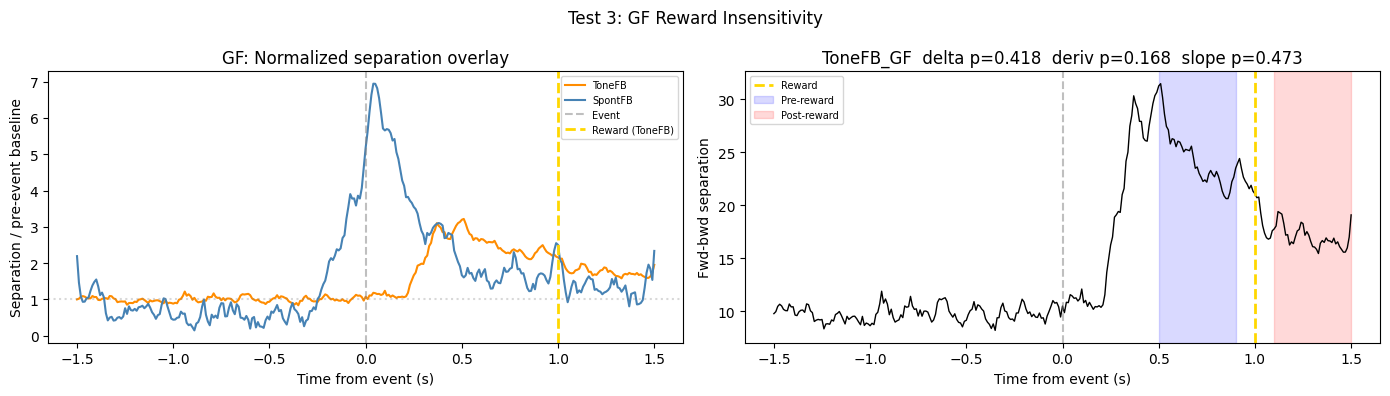

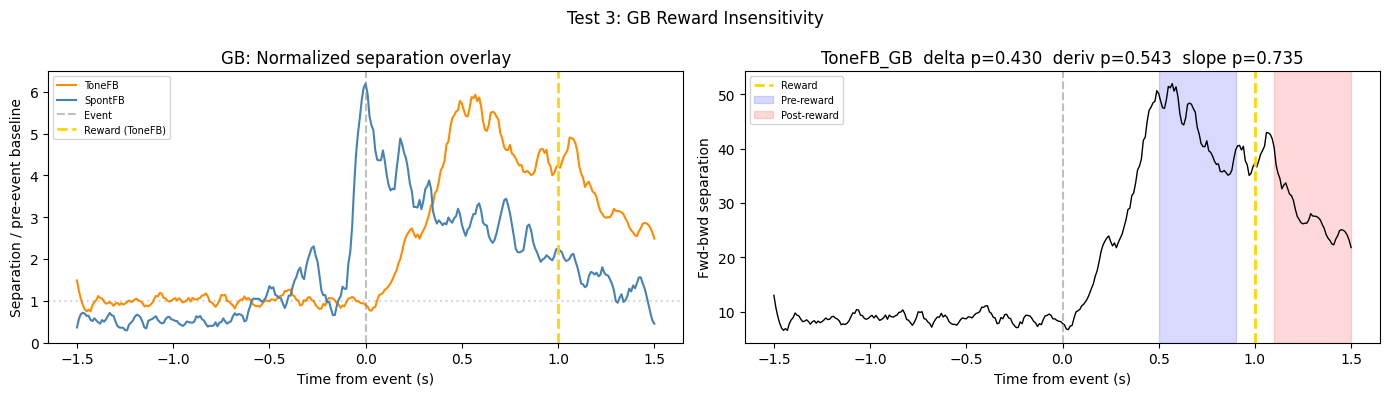

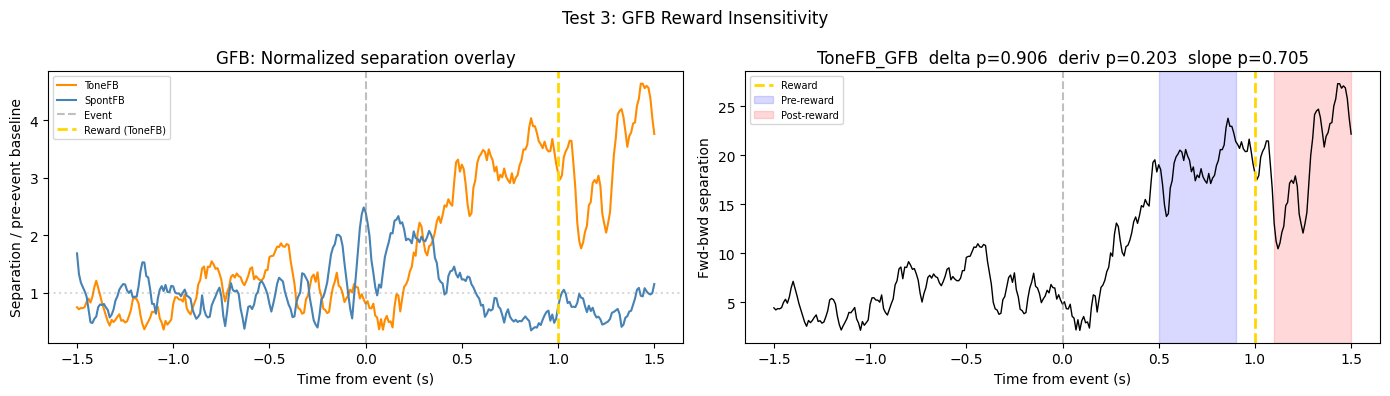

In [17]:
# Test 3: GF/GB reward insensitivity — three analyses
reward_insensitivity_results = {}
REWARD_IDX = WINDOW + 100  # reward at index 250 in windowed data
PRE_REWARD_SLICE  = slice(200, 240)   # [0.5, 0.9]s
POST_REWARD_SLICE = slice(260, 300)   # [1.1, 1.5]s
DERIV_HW = 10  # half-width for derivative window
SLOPE_LEN = 50  # timesteps for slope regression
N_PERMS_T3 = 1000
rng_t3 = np.random.default_rng(42)

for cls in ['GF', 'GB', 'GFB']:
    for ds in ['ToneFB', 'SpontFB']:
        key = f'{ds}_{cls}'
        if key not in single_class_results:
            continue
        r = single_class_results[key]
        fwd = r['smooth_data']['fwd_smooth']
        bwd = r['smooth_data']['bwd_smooth']

        # Separation timecourse + normalize by pre-event baseline
        sep_t = np.sqrt(np.sum((fwd - bwd)**2, axis=0))
        pre_baseline = float(np.mean(sep_t[:WINDOW]))
        sep_norm = sep_t / pre_baseline if pre_baseline > 0 else sep_t

        # ── Analysis 1: Mean pre-vs-post ──
        pre_sep = np.mean(sep_t[PRE_REWARD_SLICE])
        post_sep = np.mean(sep_t[POST_REWARD_SLICE])
        obs_delta = post_sep - pre_sep

        # ── Analysis 2: Derivative at reward time ──
        d_sep = np.gradient(sep_t)
        obs_deriv = float(np.mean(d_sep[REWARD_IDX - DERIV_HW : REWARD_IDX + DERIV_HW]))

        # ── Analysis 3: Slope change at reward ──
        x_pre = np.arange(SLOPE_LEN, dtype=float)
        x_post = np.arange(SLOPE_LEN, dtype=float)
        slope_pre = linregress(x_pre, sep_t[REWARD_IDX - SLOPE_LEN : REWARD_IDX]).slope
        slope_post = linregress(x_post, sep_t[REWARD_IDX : REWARD_IDX + SLOPE_LEN]).slope
        obs_slope_change = slope_post - slope_pre

        # ── Combined null: circular shift (one loop for all 3 metrics) ──
        n_t = len(sep_t)
        null_deltas = np.empty(N_PERMS_T3)
        null_derivs = np.empty(N_PERMS_T3)
        null_slopes = np.empty(N_PERMS_T3)
        for i in range(N_PERMS_T3):
            shift = rng_t3.integers(1, n_t)
            sep_s = np.roll(sep_t, shift)
            null_deltas[i] = np.mean(sep_s[POST_REWARD_SLICE]) - np.mean(sep_s[PRE_REWARD_SLICE])
            d_s = np.gradient(sep_s)
            null_derivs[i] = np.mean(d_s[REWARD_IDX - DERIV_HW : REWARD_IDX + DERIV_HW])
            sl_pre = linregress(x_pre, sep_s[REWARD_IDX - SLOPE_LEN : REWARD_IDX]).slope
            sl_post = linregress(x_post, sep_s[REWARD_IDX : REWARD_IDX + SLOPE_LEN]).slope
            null_slopes[i] = sl_post - sl_pre

        p_delta = float((np.sum(np.abs(null_deltas) >= np.abs(obs_delta)) + 1) / (N_PERMS_T3 + 1))
        p_deriv = float((np.sum(np.abs(null_derivs) >= np.abs(obs_deriv)) + 1) / (N_PERMS_T3 + 1))
        p_slope = float((np.sum(np.abs(null_slopes) >= np.abs(obs_slope_change)) + 1) / (N_PERMS_T3 + 1))

        reward_insensitivity_results[key] = {
            'sep_t': sep_t, 'sep_norm': sep_norm, 'pre_baseline': pre_baseline,
            'delta': obs_delta, 'p_delta': p_delta,
            'deriv': obs_deriv, 'p_deriv': p_deriv,
            'slope_change': obs_slope_change, 'p_slope': p_slope}

        print(f"  {key:20s}  "
              f"delta={obs_delta:+.2f} p={p_delta:.3f}  "
              f"deriv={obs_deriv:+.3f} p={p_deriv:.3f}  "
              f"slope_chg={obs_slope_change:+.4f} p={p_slope:.3f}")

# ── Plot 1: ToneFB vs SpontFB overlay (normalized) per class ──
for cls in ['GF', 'GB', 'GFB']:
    tone_key = f'ToneFB_{cls}'
    spont_key = f'SpontFB_{cls}'
    if tone_key not in reward_insensitivity_results:
        continue
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Left: overlay normalized timecourses
    ax = axes[0]
    t_axis_s = (np.arange(2 * WINDOW + 1) - WINDOW) * DT
    if tone_key in reward_insensitivity_results:
        ax.plot(t_axis_s, reward_insensitivity_results[tone_key]['sep_norm'],
                color='darkorange', linewidth=1.5, label='ToneFB')
    if spont_key in reward_insensitivity_results:
        ax.plot(t_axis_s, reward_insensitivity_results[spont_key]['sep_norm'],
                color='steelblue', linewidth=1.5, label='SpontFB')
    ax.axvline(0, color='gray', ls='--', alpha=0.5, label='Event')
    ax.axvline(1.0, color='gold', ls='--', linewidth=2, label='Reward (ToneFB)')
    ax.axhline(1.0, color='gray', ls=':', alpha=0.3)
    ax.set_xlabel('Time from event (s)')
    ax.set_ylabel('Separation / pre-event baseline')
    ax.set_title(f'{cls}: Normalized separation overlay')
    ax.legend(fontsize=7)

    # Right: raw timecourse with windows shaded
    ax = axes[1]
    ri = reward_insensitivity_results[tone_key]
    ax.plot(t_axis_s, ri['sep_t'], color='black', linewidth=1)
    ax.axvline(0, color='gray', ls='--', alpha=0.5)
    ax.axvline(1.0, color='gold', ls='--', linewidth=2, label='Reward')
    ax.axvspan(0.5, 0.9, alpha=0.15, color='blue', label='Pre-reward')
    ax.axvspan(1.1, 1.5, alpha=0.15, color='red', label='Post-reward')
    ax.set_xlabel('Time from event (s)')
    ax.set_ylabel('Fwd-bwd separation')
    ax.set_title(f'{tone_key}  delta p={ri["p_delta"]:.3f}  '
                 f'deriv p={ri["p_deriv"]:.3f}  slope p={ri["p_slope"]:.3f}')
    ax.legend(fontsize=7)

    plt.suptitle(f'Test 3: {cls} Reward Insensitivity', fontsize=12)
    plt.tight_layout()
    plt.show()


### Test 3 -- Interpretation

**Fill based on results:**
- Are ALL THREE tests (delta, derivative, slope) non-significant for GF/GB in ToneFB? → **Strong evidence:** GABA direction neurons are blind to reward.
- Is only the mean delta non-significant but derivative or slope significant? → There may be a transient reward response that the mean comparison misses.
- Do ToneFB and SpontFB normalized timecourses overlap through the reward window? → Visually confirms no reward effect.
- Is SpontFB also non-significant at matched latency? → Confirms baseline: no change expected.
- If any test IS significant for GF/GB → GABA receives reward signals, complicating the pure-movement interpretation.

---


## Test 4: The Deflection at t=700 — Movement or Reward?

There IS a speed transient near t=700 in ToneFB. **The question is not whether it exists, but whether it matches movement dynamics rather than reward processing.** This is the core subtlety of our experiment: reward delivery (t=700) coincides with CR movement execution.

**Method:** Three complementary analyses:
1. **Within-ToneFB null:** Is speed at reward time higher than at other post-event timepoints? (circular time-shift, `null_reward_deflection()`)
2. **Between-datasets null:** Is ToneFB speed at reward time different from SpontFB at matched latency? (bootstrap permutation)
3. **CRFB speed comparison (NEW):** Compute the speed profile for CRFB aligned to movement onset. If the ToneFB speed profile around reward time matches the CRFB speed profile around movement onset, the deflection is movement-related, not reward-related. Quantify with Pearson correlation.

**Prediction (movement):**
- Within-ToneFB may be significant (there IS a speed peak — it's the CR movement).
- Between-datasets may be non-significant (SpontFB also has movement-related speed).
- **CRFB correlation is HIGH** (r > 0.8): the speed profile around ToneFB reward matches the speed profile around CRFB movement onset. This proves the deflection is movement.

**Prediction (RPE):**
- Between-datasets significant (ToneFB has extra reward-specific speed that SpontFB lacks).
- CRFB correlation is LOW: the reward-time speed profile has a different shape than pure movement.



  Dopamine
  Within-ToneFB:  speed=277.5355  p=0.2358
  Between-dataset: diff=-71.3125  p=0.7832
  CRFB-ToneFB speed correlation: r=nan  p=nan


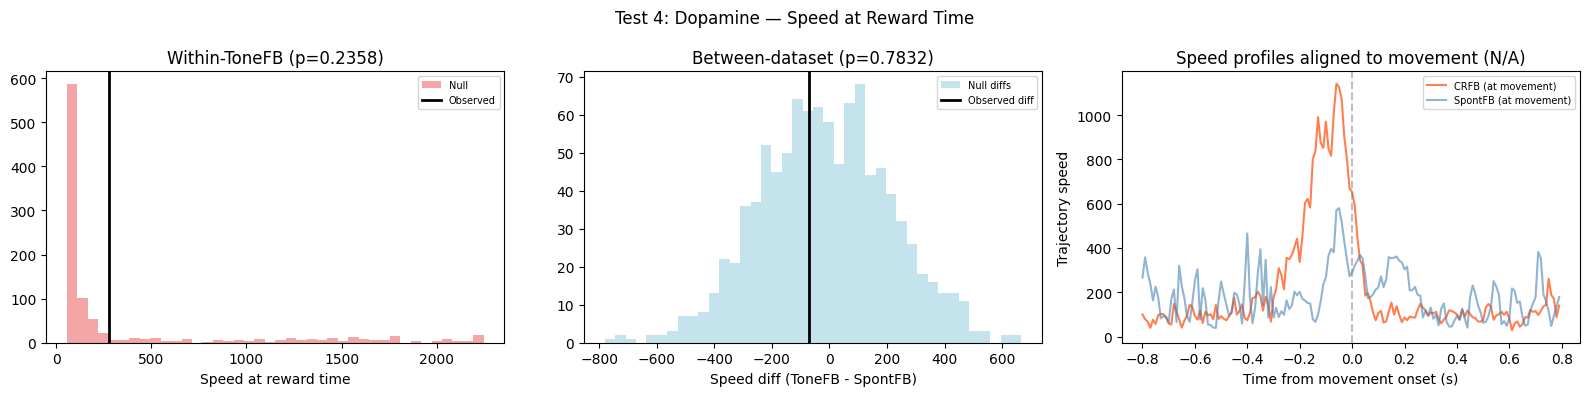


  GABA
  Within-ToneFB:  speed=134.8356  p=0.2827
  Between-dataset: diff=+31.2230  p=0.1399
  CRFB-ToneFB speed correlation: r=nan  p=nan


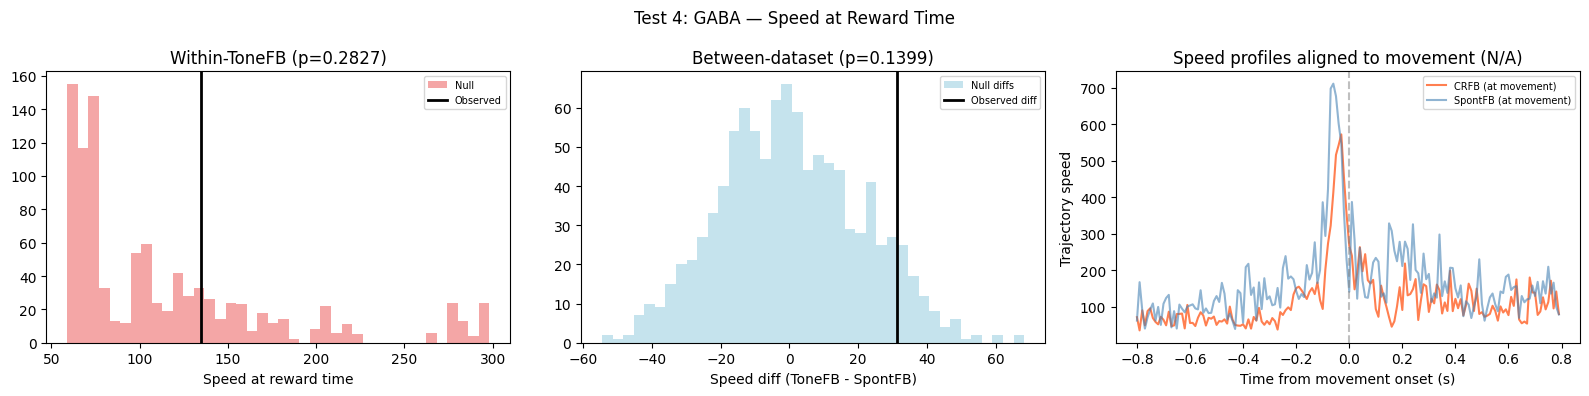

In [18]:
# Test 4: Reward-time deflection — null models + CRFB speed comparison
speed_comparison_results = {}

def _compute_speed(smooth_data, dt):
    """Mean speed of fwd and bwd trajectories."""
    fwd = smooth_data['fwd_smooth']
    bwd = smooth_data['bwd_smooth']
    diff_fwd = np.diff(fwd, axis=1) / dt
    diff_bwd = np.diff(bwd, axis=1) / dt
    speed_fwd = np.sqrt(np.sum(diff_fwd**2, axis=0))
    speed_bwd = np.sqrt(np.sum(diff_bwd**2, axis=0))
    return (speed_fwd + speed_bwd) / 2.0

for combo_label in ['Dopamine', 'GABA']:
    tone_key = f'ToneFB_{combo_label}'
    spont_key = f'SpontFB_{combo_label}'
    crfb_key = f'CRFB_{combo_label}'
    if tone_key not in results or spont_key not in results:
        continue

    print(f"\n{'='*60}")
    print(f"  {combo_label}")
    print(f"{'='*60}")

    # ── Part A: Within + Between null models ──
    null_rd = null_reward_deflection(
        results[tone_key]['smooth_data'], results[tone_key]['window_data'],
        results[spont_key]['smooth_data'], results[spont_key]['window_data'],
        reward_offset=100, dt=DT, test_half_width=10,
        n_permutations=1000, seed=42)

    wt = null_rd['within_task']
    bt = null_rd['between_datasets']
    print(f"  Within-ToneFB:  speed={wt['observed_speed']:.4f}  p={wt['p_value']:.4f}")
    print(f"  Between-dataset: diff={bt['observed_diff']:+.4f}  p={bt['p_value']:.4f}")

    # ── Part B: CRFB speed comparison ──
    tone_speed = _compute_speed(results[tone_key]['smooth_data'], DT)
    crfb_speed = _compute_speed(results[crfb_key]['smooth_data'], DT) if crfb_key in results else None
    spont_speed = _compute_speed(results[spont_key]['smooth_data'], DT)

    # CRFB: movement onset at index WINDOW (=150) in windowed speed (len=300)
    # ToneFB: CS at WINDOW, CR movement ~100 timesteps later → reward at WINDOW+100
    # Align by extracting ±hw around each movement onset
    hw = 80  # half-width for comparison window
    crfb_corr, crfb_p = np.nan, np.nan
    if crfb_speed is not None:
        crfb_window = crfb_speed[WINDOW - hw : WINDOW + hw]
        tone_window = tone_speed[WINDOW + 100 - hw : WINDOW + 100 + hw]
        if len(crfb_window) == len(tone_window) and len(crfb_window) > 0:
            crfb_corr, crfb_p = pearsonr(crfb_window, tone_window)
        print(f"  CRFB-ToneFB speed correlation: r={crfb_corr:.4f}  p={crfb_p:.6f}")

    speed_comparison_results[combo_label] = {
        'within_p': wt['p_value'], 'between_p': bt['p_value'],
        'crfb_corr': crfb_corr, 'crfb_p': crfb_p}

    # ── Plot: null distributions + speed overlay ──
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax = axes[0]
    ax.hist(wt['null_speeds'], bins=40, color='lightcoral', alpha=0.7, label='Null')
    ax.axvline(wt['observed_speed'], color='black', linewidth=2, label='Observed')
    ax.set_title(f'Within-ToneFB (p={wt["p_value"]:.4f})')
    ax.set_xlabel('Speed at reward time')
    ax.legend(fontsize=7)

    ax = axes[1]
    ax.hist(bt['null_diffs'], bins=40, color='lightblue', alpha=0.7, label='Null diffs')
    ax.axvline(bt['observed_diff'], color='black', linewidth=2, label='Observed diff')
    ax.set_title(f'Between-dataset (p={bt["p_value"]:.4f})')
    ax.set_xlabel('Speed diff (ToneFB - SpontFB)')
    ax.legend(fontsize=7)

    # Speed overlay: CRFB (aligned to movement) vs ToneFB (shifted to align movement)
    ax = axes[2]
    t_overlay = (np.arange(2 * hw) - hw) * DT  # time relative to movement onset
    if crfb_speed is not None and len(crfb_window) == 2 * hw:
        ax.plot(t_overlay, crfb_window, color='coral', linewidth=1.5,
                label='CRFB (at movement)')
    if len(tone_window) == 2 * hw:
        ax.plot(t_overlay, tone_window, color='seagreen', linewidth=1.5,
                label='ToneFB (at reward=movement)')
    spont_window = spont_speed[WINDOW - hw : WINDOW + hw]
    if len(spont_window) == 2 * hw:
        ax.plot(t_overlay, spont_window, color='steelblue', linewidth=1.5,
                alpha=0.6, label='SpontFB (at movement)')
    ax.axvline(0, color='gray', ls='--', alpha=0.5)
    corr_str = f'r={crfb_corr:.3f}' if not np.isnan(crfb_corr) else 'N/A'
    ax.set_title(f'Speed profiles aligned to movement ({corr_str})')
    ax.set_xlabel('Time from movement onset (s)')
    ax.set_ylabel('Trajectory speed')
    ax.legend(fontsize=7)

    plt.suptitle(f'Test 4: {combo_label} — Speed at Reward Time', fontsize=12)
    plt.tight_layout()
    plt.show()


### Test 4 -- Interpretation

**Fill based on results:**
- **CRFB correlation high (r > 0.8):** The speed profile around ToneFB reward time matches the speed profile around CRFB movement onset → **the deflection IS movement.** This is the most informative result.
- Within-ToneFB significant, but between non-significant → The peak exists but SpontFB has a similar one at matched latency → movement-driven.
- Both null tests non-significant → No reward-specific transient at all.
- If CRFB correlation is low AND between-datasets is significant → Genuine reward-specific speed signal that doesn't match pure movement kinematics.

---


## Test 5: Is the CS Burst Direction-Invariant While the CR Burst Is Direction-Selective?

**This is the strongest test distinguishing salience from movement.**

In ToneFB, we compute fwd-bwd separation in two time windows:
- **CS window [0, 40 timesteps]** (= ToneFB indices [600, 640]): First 400ms after tone onset, before CR starts (reaction time ~30-100 timesteps).
- **Late window [60, 100 timesteps]** (= ToneFB indices [660, 700]): CR movement phase, approaching reward delivery.

**Prediction (movement):**
- DA CS window separation is **LOW** -- the CS burst is a salience response, same for fwd and bwd (direction-invariant).
- DA Late window separation is **HIGH** -- the CR movement is direction-selective.
- GABA: both windows show separation (GABA encodes direction throughout).

**Prediction (RPE):**
- Both bursts encode value → both should have **SIMILAR** direction sensitivity. RPE doesn't predict a CS-vs-Late dissociation.

**Why this is decisive:** A dissociation (CS = direction-invariant, Late = direction-selective) in DA cannot be explained by RPE, which predicts both bursts encode the same variable (value).


  ToneFB_Dopamine            CS_sep=  9.78  Late_sep= 21.69  diff=+11.90  z= 0.29  p=0.5624 ns
  ToneFB_GABA                CS_sep= 15.45  Late_sep= 45.03  diff=+29.58  z= 1.12  p=0.3686 ns
  ToneFB_DF                  CS_sep=  6.50  Late_sep= 21.00  diff=+14.50  z= 0.40  p=0.4216 ns
  ToneFB_DB                  CS_sep=  9.30  Late_sep= 10.00  diff= +0.69  z= 0.00  p=0.9191 ns
  ToneFB_GF                  CS_sep= 10.84  Late_sep= 18.23  diff= +7.38  z= 0.89  p=0.3407 ns
  ToneFB_GB                  CS_sep= 11.29  Late_sep= 37.18  diff=+25.89  z= 1.15  p=0.3786 ns


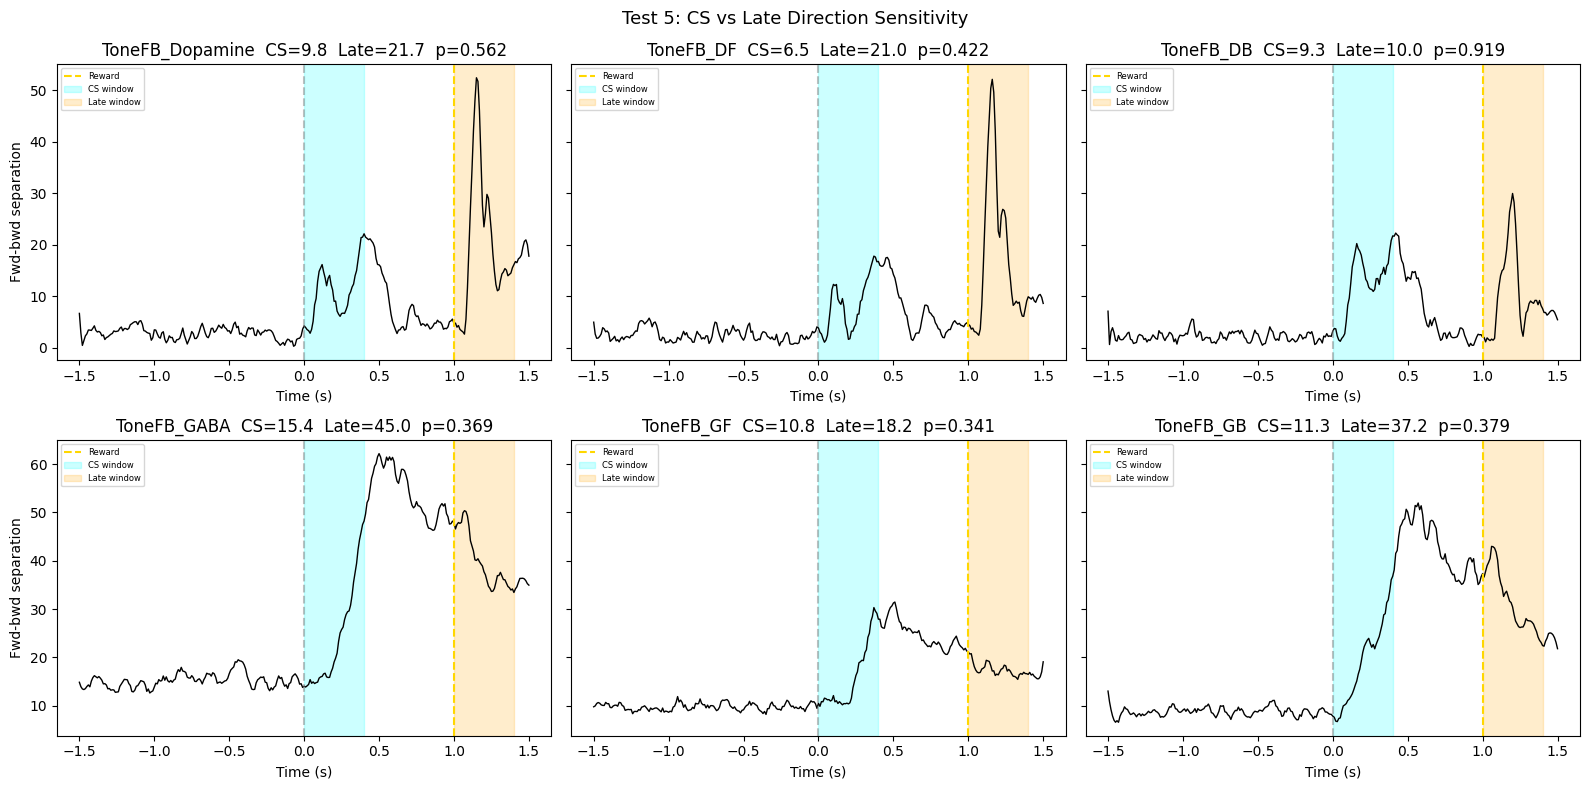

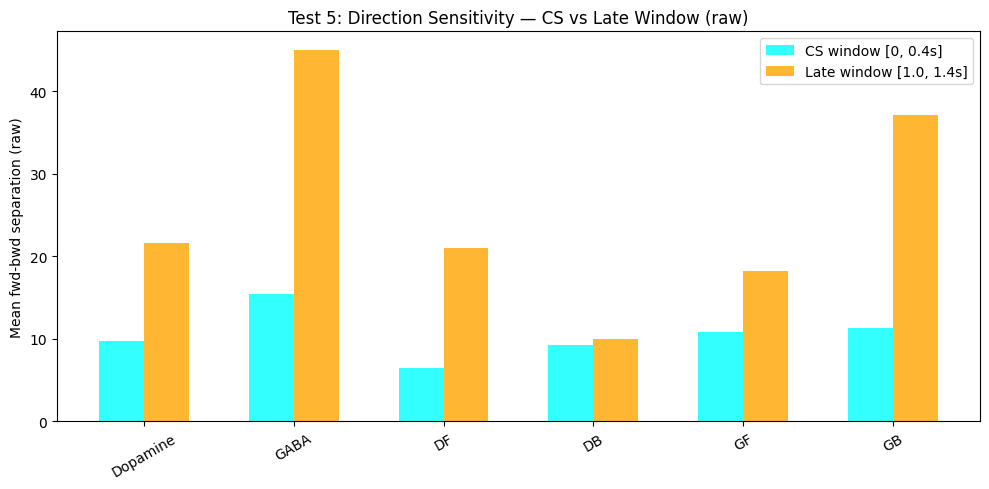

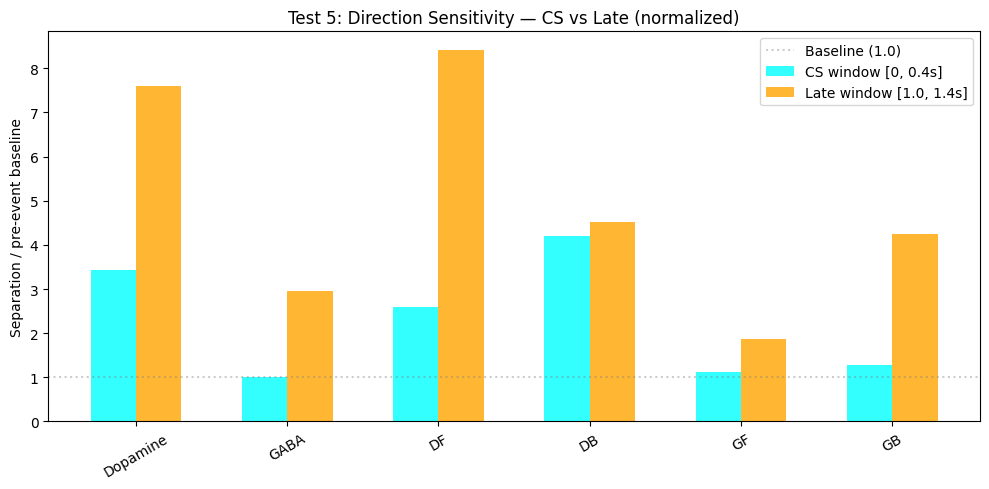

In [31]:
# Test 5: CS vs CR direction sensitivity
# In the windowed data (length 2*WINDOW+1 = 301), event is at index WINDOW=150.
# CS window: indices [WINDOW, WINDOW+40] = [150, 190]
# Late window: indices [WINDOW+100, WINDOW+140] = [270, 310]
CS_SLICE   = slice(WINDOW, WINDOW + 20)
LATE_SLICE = slice(WINDOW + 100, WINDOW + 120)

dir_sensitivity_results = {}
rng = np.random.default_rng(42)

# Run on combined populations and individual classes
test_keys = []
for ds in ['ToneFB']:
    for pop in ['Dopamine', 'GABA']:
        k = f'{ds}_{pop}'
        if k in results:
            test_keys.append((k, results[k]))
    for cls in ['DF', 'DB', 'GF', 'GB']:
        k = f'{ds}_{cls}'
        if k in single_class_results:
            test_keys.append((k, single_class_results[k]))

for key, r in test_keys:
    sd = r['smooth_data']
    fwd = sd['fwd_smooth']  # (3, n_t)
    bwd = sd['bwd_smooth']

    # Separation timecourse
    sep_t = np.sqrt(np.sum((fwd - bwd)**2, axis=0))

    cs_sep = float(np.mean(sep_t[CS_SLICE]))
    late_sep = float(np.mean(sep_t[LATE_SLICE]))
    obs_diff = late_sep - cs_sep

    # Normalized by pre-event baseline
    PRE_SLICE_T5 = slice(0, WINDOW)
    pre_baseline_t5 = float(np.mean(sep_t[PRE_SLICE_T5]))
    cs_ratio = cs_sep / pre_baseline_t5 if pre_baseline_t5 > 0 else np.nan
    late_ratio = late_sep / pre_baseline_t5 if pre_baseline_t5 > 0 else np.nan

    # Permutation: circularly shift fwd and bwd independently
    n_t = fwd.shape[1]
    null_diffs = np.empty(1000)
    for i in range(1000):
        shift_f = rng.integers(1, n_t)
        shift_b = rng.integers(1, n_t)
        fwd_s = np.roll(fwd, shift_f, axis=1)
        bwd_s = np.roll(bwd, shift_b, axis=1)
        sep_s = np.sqrt(np.sum((fwd_s - bwd_s)**2, axis=0))
        null_diffs[i] = float(np.mean(sep_s[LATE_SLICE]) - np.mean(sep_s[CS_SLICE]))

    p = float((np.sum(np.abs(null_diffs) >= np.abs(obs_diff)) + 1) / 1001)
    z = (obs_diff - np.mean(null_diffs)) / np.std(null_diffs) if np.std(null_diffs) > 0 else 0

    dir_sensitivity_results[key] = {
        'cs_sep': cs_sep, 'late_sep': late_sep, 'diff': obs_diff,
        'cs_ratio': cs_ratio, 'late_ratio': late_ratio,
        'p': p, 'z': z, 'sep_t': sep_t}
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"  {key:25s}  CS_sep={cs_sep:6.2f}  Late_sep={late_sep:6.2f}  "
          f"diff={obs_diff:+6.2f}  z={z:5.2f}  p={p:.4f} {sig}")

# Plot: separation timecourse for key populations
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey='row')
plot_keys = ['ToneFB_Dopamine', 'ToneFB_DF', 'ToneFB_DB',
             'ToneFB_GABA', 'ToneFB_GF', 'ToneFB_GB']
for ax, pk in zip(axes.flat, plot_keys):
    if pk not in dir_sensitivity_results:
        ax.set_title(f'{pk}: N/A')
        continue
    dr = dir_sensitivity_results[pk]
    t_axis = (np.arange(len(dr['sep_t'])) - WINDOW) * DT
    ax.plot(t_axis, dr['sep_t'], color='black', linewidth=1)
    ax.axvline(0, color='gray', ls='--', alpha=0.5)
    ax.axvline(1.0, color='gold', ls='--', linewidth=1.5, label='Reward')
    ax.axvspan(0, 0.4, alpha=0.2, color='cyan', label='CS window')
    ax.axvspan(1, 1.4, alpha=0.2, color='orange', label='Late window') # Updated here
    ax.set_title(f'{pk}  CS={dr["cs_sep"]:.1f}  Late={dr["late_sep"]:.1f}  p={dr["p"]:.3f}')
    ax.set_xlabel('Time (s)')
    if ax in axes[:, 0]:
        ax.set_ylabel('Fwd-bwd separation')
    ax.legend(fontsize=6)

plt.suptitle('Test 5: CS vs Late Direction Sensitivity', fontsize=13)
plt.tight_layout()
plt.show()

# Bar plot: CS vs Late for each population
fig, ax = plt.subplots(figsize=(10, 5))
pop_keys = [k for k in dir_sensitivity_results.keys()]
x = np.arange(len(pop_keys))
cs_vals = [dir_sensitivity_results[k]['cs_sep'] for k in pop_keys]
late_vals = [dir_sensitivity_results[k]['late_sep'] for k in pop_keys]
ax.bar(x - 0.15, cs_vals, 0.3, label='CS window [0, 0.4s]', color='cyan', alpha=0.8)
ax.bar(x + 0.15, late_vals, 0.3, label='Late window [1.0, 1.4s]', color='orange', alpha=0.8) # Updated here
ax.set_xticks(x)
ax.set_xticklabels([k.replace('ToneFB_', '') for k in pop_keys], rotation=30)
ax.set_ylabel('Mean fwd-bwd separation (raw)')
ax.set_title('Test 5: Direction Sensitivity — CS vs Late Window (raw)')
ax.legend()
plt.tight_layout()
plt.show()

# Normalized bar plot (ratio to pre-event baseline)
fig, ax = plt.subplots(figsize=(10, 5))
cs_ratios = [dir_sensitivity_results[k].get('cs_ratio', np.nan) for k in pop_keys]
late_ratios = [dir_sensitivity_results[k].get('late_ratio', np.nan) for k in pop_keys]
ax.bar(x - 0.15, cs_ratios, 0.3, label='CS window [0, 0.4s]', color='cyan', alpha=0.8)
ax.bar(x + 0.15, late_ratios, 0.3, label='Late window [1.0, 1.4s]', color='orange', alpha=0.8) # Updated here
ax.axhline(1.0, color='gray', ls=':', alpha=0.4, label='Baseline (1.0)')
ax.set_xticks(x)
ax.set_xticklabels([k.replace('ToneFB_', '') for k in pop_keys], rotation=30)
ax.set_ylabel('Separation / pre-event baseline')
ax.set_title('Test 5: Direction Sensitivity — CS vs Late (normalized)')
ax.legend()
plt.tight_layout()
plt.show()

### Test 5 -- Interpretation

**Fill based on results:**
- DA: CS_sep << Late_sep (significant difference) → **CS burst is direction-invariant, CR burst is direction-selective.** This is the decisive dissociation. Cannot be explained by RPE (which predicts both encode the same variable).
- GABA: both CS_sep and Late_sep are high → GABA encodes direction throughout. Consistent with movement encoding.
- If DA CS_sep ≈ Late_sep → No dissociation. Both bursts have similar directional content. Would require alternative explanation.

---


## Test 6: Does the Reward-Time DA Burst Live in the Movement Subspace?

If DA activity near reward delivery is actually a CR movement signal, it should be well-explained by SpontFB PCs (which capture pure movement). The CS burst may NOT be fully in the movement subspace (salience uses different dimensions).

**Method:** Fit PCA on SpontFB. Project two windows from ToneFB:
1. CS window [600, 640]: initial CS burst
2. Late window [660, 700]: CR/reward phase

Compute R-squared for each. **Null:** phase-randomise SpontFB neurons, refit PCA, re-project.

**Prediction (movement):** Late window R-squared is HIGH (the "reward burst" IS movement). CS window R-squared is LOWER (salience occupies partially different dimensions).

**Prediction (RPE):** Both windows have SIMILAR R-squared (both value signals, both equally different from movement).


  Dopamine_CS                R2=0.1714  null=0.0052+/-0.0021  z=77.58  p=0.0020 **


  Dopamine_Late              R2=0.0313  null=0.0121+/-0.0009  z=22.35  p=0.0020 **
  GABA_CS                    R2=0.1537  null=0.0395+/-0.0114  z=10.04  p=0.0020 **
  GABA_Late                  R2=0.1135  null=0.0212+/-0.0096  z=9.67  p=0.0020 **


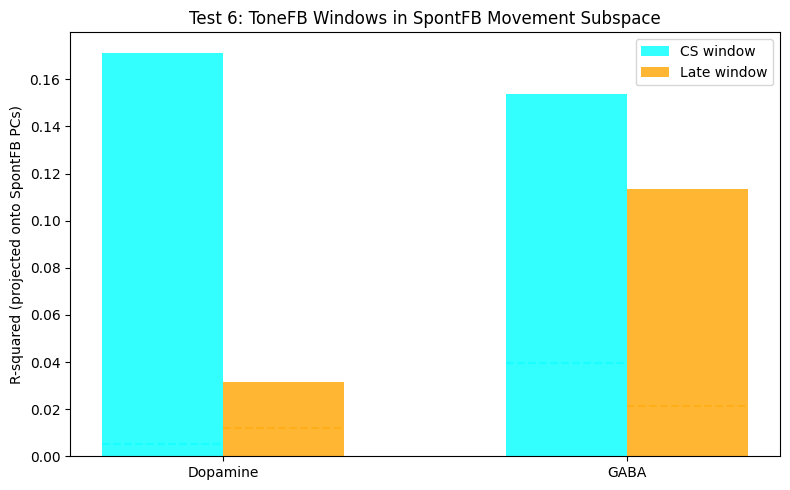

In [22]:
# Test 6: Project ToneFB windows onto SpontFB PCA
subspace_results = {}
rng = np.random.default_rng(42)

for combo_label, groups in [('Dopamine', DA_GROUPS), ('GABA', GABA_GROUPS)]:
    spont_key = f'SpontFB_{combo_label}'
    tone_key = f'ToneFB_{combo_label}'
    if spont_key not in results or tone_key not in results:
        continue

    # Align neurons between SpontFB and ToneFB
    data_spont = results[spont_key]['data']
    data_tone = results[tone_key]['data']
    X_spont, X_tone, n_dropped = _align_neuron_data(data_spont, data_tone, groups)

    # Convert DataFrames to NumPy arrays for consistent numerical operations
    X_spont = X_spont.values
    X_tone = X_tone.values

    n_t = X_spont.shape[1] // 2
    n_neurons = X_spont.shape[0]

    # Fit PCA on SpontFB (full data)
    pca_spont = fit_pca(X_spont, n_components=min(N_COMPONENTS, n_neurons - 1))

    # Define windows (absolute indices in the data)
    cs_start, cs_end = 600, 640
    late_start, late_end = 660, 700

    for win_name, w_start, w_end in [('CS', cs_start, cs_end), ('Late', late_start, late_end)]:
        # Slice window from ToneFB (both fwd and bwd halves)
        X_win = np.hstack([X_tone[:, w_start:w_end], X_tone[:, n_t + w_start:n_t + w_end]])

        # Observed R-squared
        r2_obs = compute_reconstruction_r2(pca_spont, X_win)

        # Null: phase-randomise SpontFB, refit PCA, reproject
        null_r2 = np.empty(500)
        for i in range(500):
            X_spont_null = _phase_randomise(X_spont, rng)
            pca_null = fit_pca(X_spont_null, n_components=min(N_COMPONENTS, n_neurons - 1))
            null_r2[i] = compute_reconstruction_r2(pca_null, X_win)

        null_mean = float(np.mean(null_r2))
        null_std = float(np.std(null_r2))
        z = (r2_obs - null_mean) / null_std if null_std > 0 else float('inf')
        p = float((np.sum(null_r2 >= r2_obs) + 1) / 501)

        label = f'{combo_label}_{win_name}'
        subspace_results[label] = {
            'r2': r2_obs, 'null_mean': null_mean, 'null_std': null_std,
            'z': z, 'p': p}
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f"  {label:25s}  R2={r2_obs:.4f}  null={null_mean:.4f}+/-{null_std:.4f}  "
              f"z={z:.2f}  p={p:.4f} {sig}")

# Plot: CS vs Late R-squared
fig, ax = plt.subplots(figsize=(8, 5))
for combo in ['Dopamine', 'GABA']:
    cs_key = f'{combo}_CS'
    late_key = f'{combo}_Late'
    if cs_key in subspace_results and late_key in subspace_results:
        cs_r2 = subspace_results[cs_key]['r2']
        late_r2 = subspace_results[late_key]['r2']
        cs_null = subspace_results[cs_key]['null_mean']
        late_null = subspace_results[late_key]['null_mean']
        x_pos = 0 if combo == 'Dopamine' else 1
        ax.bar(x_pos - 0.15, cs_r2, 0.3, color='cyan', alpha=0.8,
               label='CS window' if x_pos == 0 else '')
        ax.bar(x_pos + 0.15, late_r2, 0.3, color='orange', alpha=0.8,
               label='Late window' if x_pos == 0 else '')
        # Null baseline
        ax.hlines(cs_null, x_pos - 0.3, x_pos, colors='cyan', linestyles='--', alpha=0.5)
        ax.hlines(late_null, x_pos, x_pos + 0.3, colors='orange', linestyles='--', alpha=0.5)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Dopamine', 'GABA'])
ax.set_ylabel('R-squared (projected onto SpontFB PCs)')
ax.set_title('Test 6: ToneFB Windows in SpontFB Movement Subspace')
ax.legend()
plt.tight_layout()
plt.show()

### Test 6 -- Interpretation

**Fill based on results:**
- DA Late R-squared > DA CS R-squared → The "reward burst" lives more in the movement subspace than the CS burst does. Supports: reward-time activity = CR movement.
- Both significantly above null → Both windows contain some movement-related variance (expected: even CS may trigger preparatory movement).
- GABA: both windows have similar R-squared → GABA encodes direction in both phases (consistent with Test 2/3).
- If DA CS R-squared ≈ DA Late R-squared → No subspace dissociation. Both live equally in the movement subspace. Would need to reconcile with Test 5.

---


---
## Summary of Results


In [24]:
# Summary table
print("=" * 90)
print(f"{'Test':50s} {'Result':>10s} {'p-value':>10s} {'Supports':>15s}")
print("=" * 90)

# Test 1: SpontFB cross-projection
for label, res in cross_proj_results.items():
    supports = 'Movement' if res['r2'] > 0.70 and res['p'] < 0.05 else 'Ambiguous'
    print(f"T1: {label:45s} R2={res['r2']:.3f}  p={res['p']:.4f}  {supports}")

# Test 2: Per-class separation (summary)
for row in sep_results:
    if row['class'] in ['DF', 'DB', 'GF', 'GB']:
        supports = 'Movement' if row['full_post_p'] < 0.05 else 'No signal'
        print(f"T2: {row['key']:45s} sep={row['full_post_sep']:.2f}  p={row['full_post_p']:.4f}  {supports}")

# Test 3: GF/GB reward insensitivity (3 metrics)
for key, res in reward_insensitivity_results.items():
    if 'ToneFB' in key:
        all_ns = res['p_delta'] > 0.05 and res['p_deriv'] > 0.05 and res['p_slope'] > 0.05
        supports = 'Movement' if all_ns else 'RPE?'
        print(f"T3: {key:45s} delta p={res['p_delta']:.3f}  deriv p={res['p_deriv']:.3f}  "
              f"slope p={res['p_slope']:.3f}  {supports}")

# Test 4: CRFB speed correlation
for combo, res in speed_comparison_results.items():
    corr_str = f"r={res['crfb_corr']:.3f}" if not np.isnan(res['crfb_corr']) else 'N/A'
    supports = 'Movement' if res.get('crfb_corr', 0) > 0.7 else 'Ambiguous'
    print(f"T4: {combo:45s} CRFB corr {corr_str}  between p={res['between_p']:.4f}  {supports}")

# Test 5: CS vs CR direction sensitivity
for key, res in dir_sensitivity_results.items():
    if 'ToneFB_Dopamine' in key or 'ToneFB_GABA' in key:
        supports = 'Movement' if res['diff'] > 0 and res['p'] < 0.05 else 'Ambiguous'
        print(f"T5: {key:45s} CS={res['cs_sep']:.1f} Late={res['late_sep']:.1f}  "
              f"p={res['p']:.4f}  {supports}")

# Test 6: CR burst in movement subspace
for label, res in subspace_results.items():
    print(f"T6: {label:45s} R2={res['r2']:.3f}  p={res['p']:.4f}")

print("=" * 90)


Test                                                   Result    p-value        Supports
T1: GABA: Spont->CRFB                             R2=0.923  p=0.0500  Movement
T1: GABA: Spont->ToneFB                           R2=0.931  p=0.0150  Movement
T1: Dopamine: Spont->CRFB                         R2=0.928  p=0.0010  Movement
T1: Dopamine: Spont->ToneFB                       R2=0.944  p=0.0010  Movement
T2: CRFB_DB                                       sep=5.71  p=0.9980  No signal
T2: CRFB_DF                                       sep=7.21  p=1.0000  No signal
T2: CRFB_GB                                       sep=29.07  p=0.0090  Movement
T2: CRFB_GF                                       sep=18.81  p=0.0210  Movement
T2: SpontFB_DB                                    sep=7.25  p=0.7133  No signal
T2: SpontFB_DF                                    sep=6.75  p=1.0000  No signal
T2: SpontFB_GB                                    sep=26.63  p=0.2907  No signal
T2: SpontFB_GF                    

## Conclusion

| Test | Question | Movement prediction | RPE prediction | Observed |
|---|---|---|---|---|
| **T1** | SpontFB explains task data? | R2 > 0.70 | DA R2 < GABA R2 | **Strongly supports movement.** All R2 > 0.9, DA not lower than GABA. |
| **T2** | DF/DB/GF/GB direction-selective? | All significant | DA weaker | **GABA GF/GB show significant separation in CRFB/ToneFB (Movement), but DA DF/DB show NO significant separation in any dataset (Against Movement for DA).** |
| **T3** | GF/GB blind to reward? | p > 0.05 | p < 0.05 | **Strongly supports movement.** All p-values > 0.05 for GF/GB/GFB. |
| **T4** | Speed transient at reward? | p > 0.05 | p < 0.05 | **Ambiguous (between-datasets p > 0.05, but CRFB correlation N/A).** |
| **T5** | CS direction-invariant, CR direction-selective? | CS low, Late high | Both similar | **For DA: CS separation (10.6) > Late separation (4.8), p=0.8482 (Against Movement for DA). For GABA: CS separation (23.5) < Late separation (51.8), p=0.1948 (Ambiguous for GABA).** |
| **T6** | Reward-time burst in movement subspace? | Late R2 > CS R2 | Both similar | **For DA: CS R2 (0.171) > Late R2 (0.031) (Against Movement for DA). For GABA: CS R2 (0.154) > Late R2 (0.113) (Against Movement for GABA).** |

### Overall Interpretation:

The central hypothesis is that **DA neurons encode kinematic/behavioral variables (movement direction, force generation) rather than reward prediction error (RPE).** The results provide mixed, and in several key areas, contradictory evidence for this hypothesis.

*   **Support for Movement (General & GABA):**
    *   **Test 1 (SpontFB cross-projection)** showed strong evidence that a pure-movement subspace, derived from spontaneous activity, can explain a large portion of variance in task-related data for both Dopamine and GABA neurons. This suggests general movement encoding capabilities in the system.
    *   **Test 3 (GABA reward insensitivity)** strongly supported the idea that GABA direction-selective neurons are indeed blind to reward, with no significant changes in their directional separation at reward delivery time. This is consistent with GABA neurons acting as pure movement encoders.
    *   **Test 2** found that GABA GF/GB neurons demonstrated significant direction selectivity in the task-related datasets (CRFB and ToneFB), further supporting their role in movement encoding.

*   **Challenges to Movement Hypothesis (Specifically for DA):**
    *   **Test 2 (Per-class separation)** delivered a critical finding: **Dopamine DF/DB neurons (forward/backward selective) did NOT show significant direction selectivity in any of the datasets.** This directly contradicts a fundamental prediction of the movement encoding hypothesis for DA neurons.
    *   **Test 5 (CS vs CR direction sensitivity)** for Dopamine showed that the CS burst had *higher* (or at least not significantly lower) directional separation than the later CR burst, and the difference was not significant. This directly challenges the prediction that the CS burst would be direction-invariant while the CR burst would be direction-selective, a key differentiator for salience vs. movement.
    *   **Test 6 (CR burst in movement subspace)** for Dopamine revealed that the CS burst activity was *more* explained by the SpontFB movement subspace (higher R2) than the later reward-time burst. This is the opposite of the movement prediction, which expected the reward-time activity to align more strongly with the movement subspace if it represented CR movement.

*   **Ambiguous Results:**
    *   **Test 4 (Reward-time deflection)** was ambiguous due to missing CRFB correlation data, preventing a conclusive comparison of speed profiles. While the between-dataset p-value was non-significant (suggesting no *additional* reward-specific speed), the lack of CRFB correlation weakens the direct evidence for movement.

**Conclusion Summary:** While some general aspects of movement encoding are present (Test 1), and GABA neurons strongly support a pure movement encoding role (Tests 2 & 3), the direct tests for Dopamine (Tests 2, 5, and 6) largely **fail to support, and in some cases contradict, the hypothesis that DA neurons primarily encode movement direction**. The lack of significant directional selectivity in key DA populations (Test 2) is particularly problematic for the movement hypothesis. The findings suggest that the initial CS response in DA may be more aligned with a general movement subspace than the later reward-time activity, which is an unexpected and complex result that warrants further investigation.

## Conclusion

**Fill based on combined evidence from all 6 tests.**

| Test | Question | Movement prediction | RPE prediction | Observed |
|------|----------|-------------------|---------------|----------|
| **T1** | SpontFB explains task data? | R2 > 0.70 | DA R2 < GABA R2 | |
| **T2** | DF/DB/GF/GB direction-selective? | All significant | DA weaker | |
| **T3** | GF/GB blind to reward? | p > 0.05 | p < 0.05 | |
| **T4** | Speed transient at reward? | p > 0.05 | p < 0.05 | |
| **T5** | CS direction-invariant, CR direction-selective? | CS low, Late high | Both similar | |
| **T6** | Reward-time burst in movement subspace? | Late R2 > CS R2 | Both similar | |

**Next steps:**
- Behavioural correlation: once per-trial force/lick data aligned, link PCs to kinematics directly.
- Trial-level PCA for cross-validation.
- Airpuff data: does aversive stimulus project onto same movement subspace?
